# BCSE209P Machine Learning-(FALL 2026) Laboratory Template

## SCOPE, VIT Chennai

### Student Information

- **Student Name:** Shrri Dharshan D R
- **Register Number:** 23BPS1090
- **Course Code:** BCSE209P
- **Course Title:** Machine Learning Laboratory
- **Faculty:** Dr. S. Shridevi
- **Experiment No.:** 6
- **Date:** 07.09.2026

---

In [1]:
# Student Identification

AUTHOR        = "Shrri Dharshan D R"
REGISTER_NO   = "23BPS1090"
COURSE        = "BCSE209P-Machine Learning Laboratory"
FACULTY       = "Dr. S. Shridevi"
INSTITUTION   = "SCOPE, VIT Chennai"
NOTEBOOK_ID   = "ML-LAB-06"

print("Notebook Loaded Successfully")

Notebook Loaded Successfully


In [2]:
# Notebook Fingerprint

import hashlib
import datetime

fingerprint = hashlib.sha256(
    (AUTHOR + REGISTER_NO + COURSE + NOTEBOOK_ID +
     str(datetime.datetime.now())).encode()
).hexdigest()

print("Notebook Fingerprint:")
print(fingerprint)

Notebook Fingerprint:
9989af99e1f84b108a04b4f8cab1c10b60b5a39a5eeedd6557906306954b82b4


# Experiment Details

## Objective

To apply **DBSCAN (Density-Based Spatial Clustering of Applications with Noise)** on the
*Sales Transactions Dataset Weekly* (UCI ML Repository, ID: 396), in order to discover
natural product groupings based on weekly sales patterns over 52 weeks, and to evaluate
cluster quality using the **Silhouette Score**.

---

## Theory

### Clustering

Clustering is an unsupervised learning technique that partitions unlabelled data into
groups (clusters) such that intra-cluster similarity is maximised and inter-cluster
similarity is minimised. No ground-truth labels are used during training.

### DBSCAN (Density-Based Spatial Clustering of Applications with Noise)

DBSCAN groups points that lie within radius $\varepsilon$ of at least `min_samples`
neighbours (core points). Points reachable from a core point but not themselves core
points are called **border points**. Points satisfying neither condition are labelled
**noise** ($= -1$).

Key concepts:

- **Core Point** — a point with at least `min_samples` neighbours within radius $\varepsilon$
- **Border Point** — within $\varepsilon$ of a core point but with fewer than `min_samples` own neighbours
- **Noise Point** — not reachable from any core point; labelled $-1$

Unlike K-Means, DBSCAN:
- Does **not** require specifying the number of clusters in advance
- Discovers clusters of **arbitrary shape**
- Is robust to **outliers** (noise products with irregular weekly patterns)
- Can fail when clusters have very different densities

### Selecting Parameters

**EPS ($\varepsilon$)** — The neighbourhood radius. Chosen using the **K-Distance Graph**:
sort all points by their distance to their $k$-th nearest neighbour and locate the
"elbow" — the point where distances begin to increase sharply.

**min_samples** — The minimum number of points required to form a dense region.
A common heuristic is $\text{min\_samples} = 2 \times d$ where $d$ is the number of features,
or simply 5 for most datasets.

### Silhouette Score

Measures how similar each point is to its own cluster compared to the nearest
neighbouring cluster:

$$s(i) = \frac{b(i) - a(i)}{\max(a(i),\, b(i))}$$

where $a(i)$ = mean intra-cluster distance, $b(i)$ = mean nearest-cluster distance.
Range: $[-1, +1]$; higher is better. Computed excluding noise points.

### Feature Reduction — PCA

PCA projects high-dimensional data to a low-dimensional subspace while preserving
maximum variance, enabling 2-D visualisation of clustering results:

$$\mathbf{Z} = \mathbf{X}\mathbf{W}_r, \quad \mathbf{W}_r \in \mathbb{R}^{d \times r}$$

### Feature Scaling — StandardScaler

DBSCAN is based on Euclidean distance and is therefore scale-sensitive. StandardScaler
transforms each feature to zero mean and unit variance before clustering:

$$x' = \frac{x - \mu}{\sigma}$$

---

## Dataset

- **Name:** Sales Transactions Dataset Weekly
- **Source:** UCI Machine Learning Repository (ID: 396)  
  — https://archive.ics.uci.edu/dataset/396/sales+transactions+dataset+weekly
- **Author:** James Tan, 2014
- **Total Instances:** 811 products (rows)
- **Raw Format:** Single `.csv` file — Product_Code as ID, W0–W51 (52 integer weekly
  sales counts), Normalized 0–51 (52 normalised real-valued columns)
- **Features used:** Raw weekly counts W0–W51 (52 features), scaled before clustering
- **Target / Labels:** None (unsupervised)
- **Task Type:** Clustering — product sales-pattern segmentation
- **Missing Values:** None
- **Licence:** CC BY 4.0

---

In [3]:
# Step 1 — Import required libraries

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import os, io, warnings
import urllib.request

warnings.filterwarnings("ignore")

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score

pd.set_option("display.max_columns", None)
print("All libraries imported successfully.")

All libraries imported successfully.


In [4]:
# Step 2 — Download and load the UCI Sales Transactions Dataset Weekly (ID: 396)
#
# Primary  : ucimlrepo  (official UCI Python client)
# Fallback : direct CSV download from the UCI static archive

df_raw = None

# ── Primary: ucimlrepo ───────────────────────────────────────────
try:
    from ucimlrepo import fetch_ucirepo
    print("Attempting download via ucimlrepo …")
    ds     = fetch_ucirepo(id=396)
    df_raw = ds.data.features.copy()
    # ucimlrepo strips the ID column; restore Product_Code from original
    df_raw.insert(0, "Product_Code", ds.data.ids["Product_Code"].values)
    print("Downloaded via ucimlrepo.")

except Exception as e:
    print(f"ucimlrepo failed ({e}). Trying direct CSV download …")

# ── Fallback: direct CSV ─────────────────────────────────────────
if df_raw is None:
    DATA_URL = (
        "https://archive.ics.uci.edu/ml/machine-learning-databases/00396/"
        "Sales_Transactions_Dataset_Weekly.csv"
    )
    csv_path = "Sales_Transactions_Dataset_Weekly.csv"
    if not os.path.exists(csv_path):
        print("Downloading CSV …")
        urllib.request.urlretrieve(DATA_URL, csv_path)
        print("Download complete.")
    else:
        print("CSV already present.")
    df_raw = pd.read_csv(csv_path)
    print("Loaded from local CSV.")

print("\nDataset loaded successfully.")
print("Shape:", df_raw.shape)
print(df_raw.iloc[:3, :8])

Attempting download via ucimlrepo …
Downloaded via ucimlrepo.

Dataset loaded successfully.
Shape: (811, 107)
  Product_Code  W0  W1  W2  W3  W4  W5  W6
0           P1  11  12  10   8  13  12  14
1           P2   7   6   3   2   7   1   6
2           P3   7  11   8   9  10   8   7


In [5]:
# Step 3 — Dataset overview

print("Dataset  : Sales Transactions Dataset Weekly")
print("Shape    :", df_raw.shape, "  (products × features)")
print("Source   : UCI ML Repository (ID: 396)")
print("Task     : Unsupervised Clustering — product sales-pattern segmentation")
print("Period   : 52 consecutive weeks (W0 – W51)")
print("Unit     : Weekly purchased quantity (integer counts)")

Dataset  : Sales Transactions Dataset Weekly
Shape    : (811, 107)   (products × features)
Source   : UCI ML Repository (ID: 396)
Task     : Unsupervised Clustering — product sales-pattern segmentation
Period   : 52 consecutive weeks (W0 – W51)
Unit     : Weekly purchased quantity (integer counts)


In [6]:
# Step 4 — Explore dataset structure

print("Shape       :", df_raw.shape)
print("Column names (first 10):", df_raw.columns.tolist()[:10], "…")
print("\nFirst 5 rows (first 8 columns):")
print(df_raw.iloc[:5, :8])

Shape       : (811, 107)
Column names (first 10): ['Product_Code', 'W0', 'W1', 'W2', 'W3', 'W4', 'W5', 'W6', 'W7', 'W8'] …

First 5 rows (first 8 columns):
  Product_Code  W0  W1  W2  W3  W4  W5  W6
0           P1  11  12  10   8  13  12  14
1           P2   7   6   3   2   7   1   6
2           P3   7  11   8   9  10   8   7
3           P4  12   8  13   5   9   6   9
4           P5   8   5  13  11   6   7   9


In [7]:
# Step 5 — Data types and basic counts

print("Data Types (value counts):")
print(df_raw.dtypes.value_counts())
print("\nNumber of products (rows) :", df_raw.shape[0])
print("Total columns              :", df_raw.shape[1])
print("  → 1 Product_Code (ID)")
print("  → 52 raw weekly counts  (W0–W51)")
print("  → 52 normalised columns (Normalized 0–51)")

Data Types (value counts):
int64      54
float64    52
str         1
Name: count, dtype: int64

Number of products (rows) : 811
Total columns              : 107
  → 1 Product_Code (ID)
  → 52 raw weekly counts  (W0–W51)
  → 52 normalised columns (Normalized 0–51)


In [8]:
# Step 6 — Check for missing values and duplicates

missing = df_raw.isnull().sum()
print("Missing values per column (first 10):")
print(missing.head(10))
print(f"\nTotal missing values : {missing.sum()}")
print(f"Duplicate rows       : {df_raw.duplicated().sum()}")

# Count products with all-zero sales (dormant products)
week_cols = [c for c in df_raw.columns if c.startswith("W") and c[1:].isdigit()]
zero_products = (df_raw[week_cols] == 0).all(axis=1).sum()
print(f"\nProducts with all-zero weekly sales: {zero_products}")

Missing values per column (first 10):
Product_Code    0
W0              0
W1              0
W2              0
W3              0
W4              0
W5              0
W6              0
W7              0
W8              0
dtype: int64

Total missing values : 0
Duplicate rows       : 0

Products with all-zero weekly sales: 0


In [9]:
# Step 7 — Statistical summary

week_cols = [c for c in df_raw.columns if c.startswith("W") and c[1:].isdigit()]
print(f"Number of weekly feature columns: {len(week_cols)}")
print("\nStatistical summary — weekly sales (first 6 weeks):")
print(df_raw[week_cols[:6]].describe().round(2))

total_sales = df_raw[week_cols].sum(axis=1)
print("\nPer-product total sales across 52 weeks — statistics:")
print(total_sales.describe().round(2))

Number of weekly feature columns: 52

Statistical summary — weekly sales (first 6 weeks):
           W0      W1      W2      W3      W4      W5
count  811.00  811.00  811.00  811.00  811.00  811.00
mean     8.90    9.13    9.39    9.72    9.57    9.47
std     12.07   12.56   13.05   13.55   13.10   12.82
min      0.00    0.00    0.00    0.00    0.00    0.00
25%      0.00    0.00    0.00    0.00    0.00    0.00
50%      3.00    3.00    3.00    4.00    4.00    3.00
75%     12.00   12.00   12.00   13.00   13.00   12.50
max     54.00   53.00   56.00   59.00   61.00   52.00

Per-product total sales across 52 weeks — statistics:
count     811.00
mean      462.75
std       593.86
min         1.00
25%        21.00
50%       199.00
75%       575.00
max      2220.00
dtype: float64


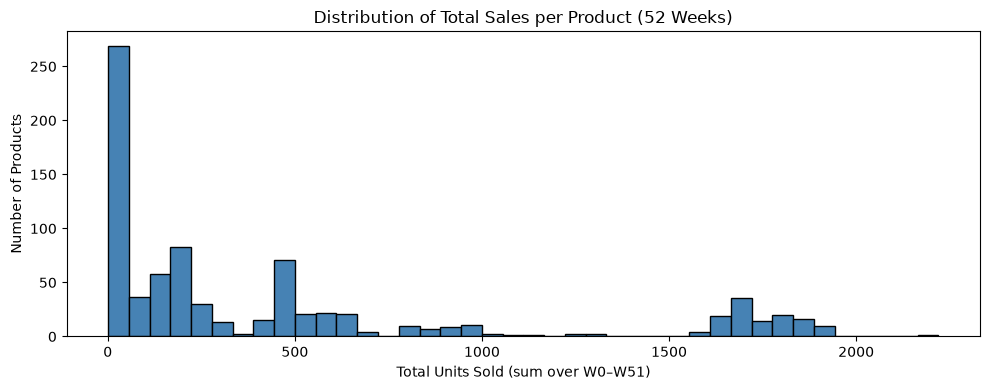

Total sales stats:
count     811.00
mean      462.75
std       593.86
min         1.00
25%        21.00
50%       199.00
75%       575.00
max      2220.00
dtype: float64


In [10]:
# Step 8 — Exploratory Data Analysis

week_cols = [c for c in df_raw.columns if c.startswith("W") and c[1:].isdigit()]

# 8a. Distribution of total sales per product
total_sales = df_raw[week_cols].sum(axis=1)

plt.figure(figsize=(10, 4))
plt.hist(total_sales, bins=40, color="steelblue", edgecolor="black")
plt.title("Distribution of Total Sales per Product (52 Weeks)")
plt.xlabel("Total Units Sold (sum over W0–W51)")
plt.ylabel("Number of Products")
plt.tight_layout()
plt.show()

print("Total sales stats:")
print(total_sales.describe().round(2))

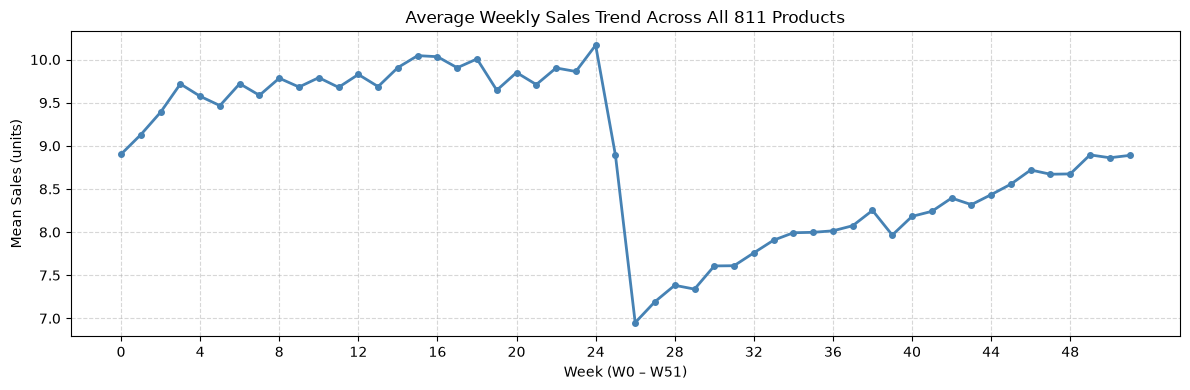

In [11]:
# 8b. Average weekly sales trend across all products

weekly_mean = df_raw[week_cols].mean(axis=0)

plt.figure(figsize=(12, 4))
plt.plot(range(52), weekly_mean.values, color="steelblue", lw=2, marker="o", markersize=4)
plt.xlabel("Week (W0 – W51)")
plt.ylabel("Mean Sales (units)")
plt.title("Average Weekly Sales Trend Across All 811 Products")
plt.xticks(range(0, 52, 4))
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

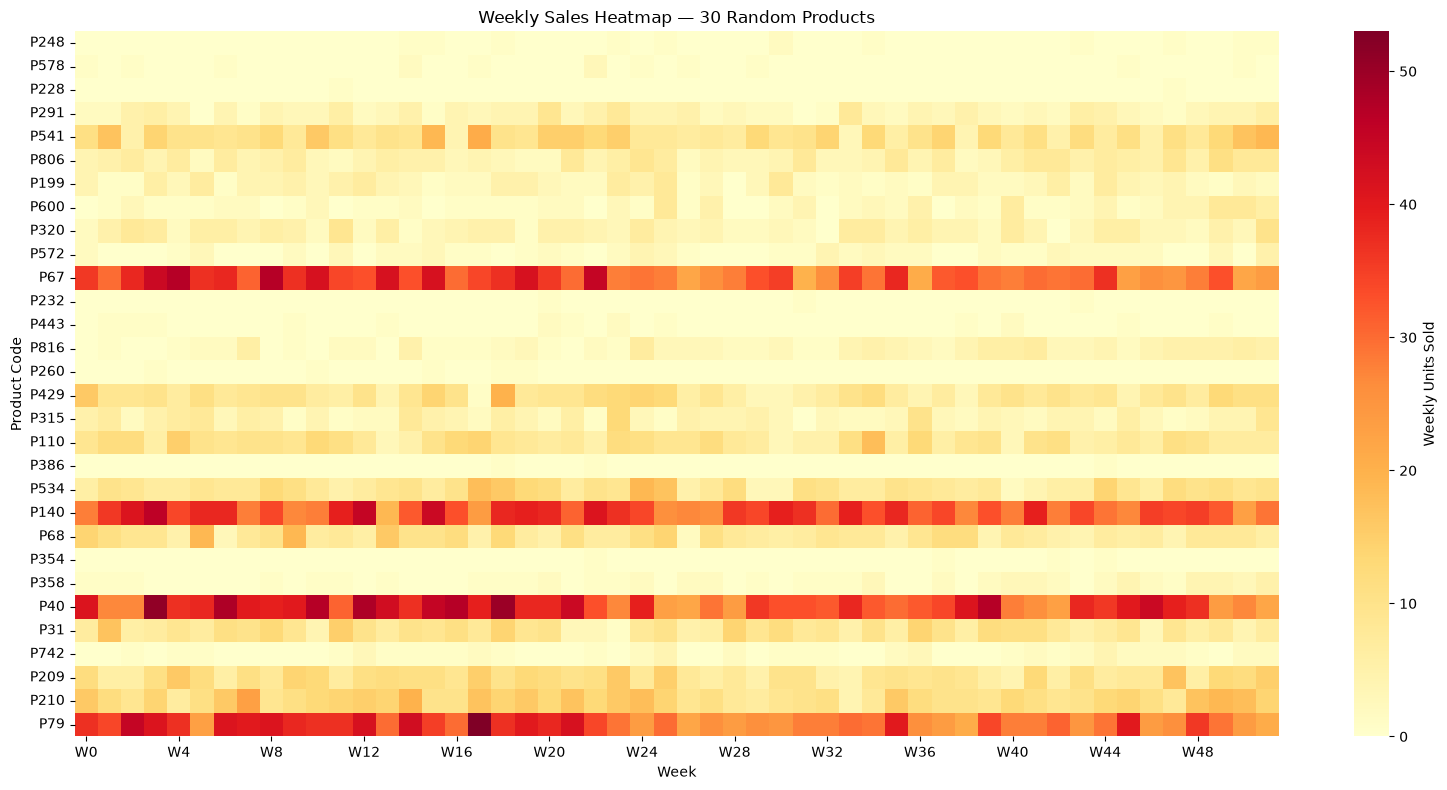

In [12]:
# 8c. Heatmap — weekly sales for a random sample of 30 products

sample_idx = df_raw.sample(30, random_state=42).index
sample_df  = df_raw.loc[sample_idx, week_cols]
sample_df.index = df_raw.loc[sample_idx, "Product_Code"].values

plt.figure(figsize=(16, 8))
sns.heatmap(
    sample_df,
    cmap="YlOrRd",
    xticklabels=4,
    yticklabels=True,
    cbar_kws={"label": "Weekly Units Sold"}
)
plt.title("Weekly Sales Heatmap — 30 Random Products")
plt.xlabel("Week")
plt.ylabel("Product Code")
plt.tight_layout()
plt.show()

In [13]:
# Step 9 — Select weekly features and apply StandardScaler

week_cols = [c for c in df_raw.columns if c.startswith("W") and c[1:].isdigit()]
X = df_raw[week_cols].copy()

print("Selected features (weekly counts):")
print(week_cols)
print(f"\nFeature matrix shape: {X.shape}")

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\nData standardized successfully.")
print("Mean after standardization :", round(X_scaled.mean(), 6))
print("Std  after standardization :", round(X_scaled.std(),  6))
print("\nPreprocessing complete.")

Selected features (weekly counts):
['W0', 'W1', 'W2', 'W3', 'W4', 'W5', 'W6', 'W7', 'W8', 'W9', 'W10', 'W11', 'W12', 'W13', 'W14', 'W15', 'W16', 'W17', 'W18', 'W19', 'W20', 'W21', 'W22', 'W23', 'W24', 'W25', 'W26', 'W27', 'W28', 'W29', 'W30', 'W31', 'W32', 'W33', 'W34', 'W35', 'W36', 'W37', 'W38', 'W39', 'W40', 'W41', 'W42', 'W43', 'W44', 'W45', 'W46', 'W47', 'W48', 'W49', 'W50', 'W51']

Feature matrix shape: (811, 52)

Data standardized successfully.
Mean after standardization : -0.0
Std  after standardization : 1.0

Preprocessing complete.


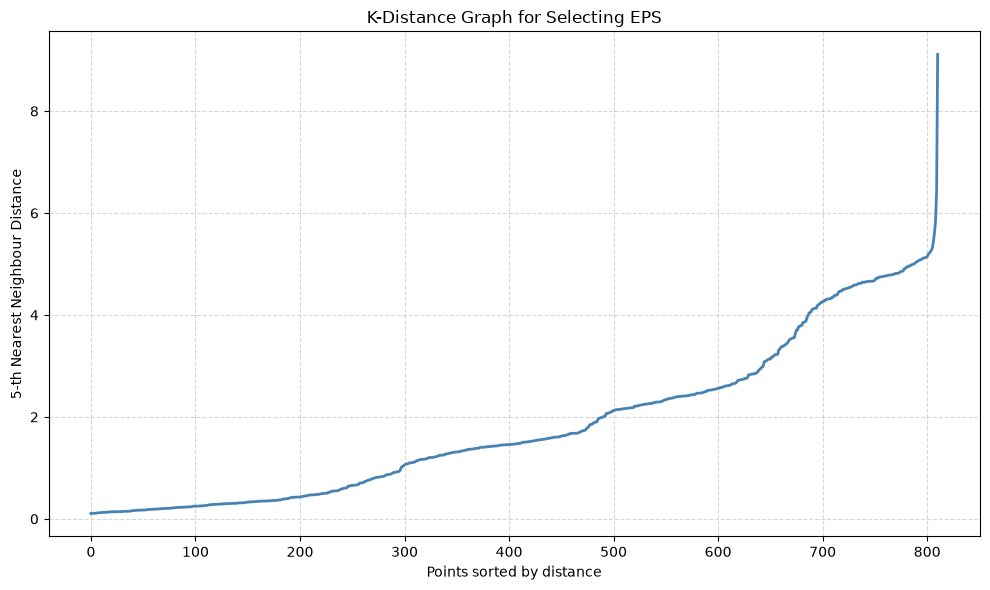


Selected min_samples = 5
Inspect the elbow in the graph above to choose EPS.


In [14]:
# Step 10 — K-Distance Graph to select EPS
#
# DBSCAN requires:
#   eps          -> neighbourhood radius
#   min_samples  -> minimum number of points
#
# The elbow of the k-distance curve provides a useful starting estimate for EPS.

min_samples = 5

neighbors     = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(X_scaled)
distances, _  = neighbors_fit.kneighbors(X_scaled)

# Distance to kth nearest neighbour, sorted ascending
k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(10, 6))
plt.plot(k_distances, color="steelblue", lw=2)
plt.xlabel("Points sorted by distance")
plt.ylabel(f"{min_samples}-th Nearest Neighbour Distance")
plt.title("K-Distance Graph for Selecting EPS")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

print(f"\nSelected min_samples = {min_samples}")
print("Inspect the elbow in the graph above to choose EPS.")

In [15]:
# Step 11 — Choose EPS from the K-Distance Graph

# The elbow typically appears where the curve begins to rise steeply.
# For this 52-feature standardised dataset, EPS ≈ 3.5 – 4.5 is reasonable.
# We start with eps_value = 4.0 and refine after examining cluster counts.

eps_value = 4.0

print("Selected parameters:")
print(f"  EPS         = {eps_value}")
print(f"  min_samples = {min_samples}")

Selected parameters:
  EPS         = 4.0
  min_samples = 5


In [16]:
# Step 12 — Apply DBSCAN

dbscan = DBSCAN(eps=eps_value, min_samples=min_samples)
labels = dbscan.fit_predict(X_scaled)

print("=" * 60)
print("DBSCAN RESULTS")
print("=" * 60)

unique_labels = np.unique(labels)
print("\nCluster labels:", unique_labels)

print("\nCluster sizes:")
for label in unique_labels:
    name  = "Noise" if label == -1 else f"Cluster {label}"
    count = int(np.sum(labels == label))
    print(f"  {name}: {count} products")

DBSCAN RESULTS

Cluster labels: [-1  0  1]

Cluster sizes:
  Noise: 120 products
  Cluster 0: 686 products
  Cluster 1: 5 products


In [17]:
# Step 13 — Identify noise points and core samples

noise_mask   = labels == -1
core_samples = dbscan.core_sample_indices_

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise    = int(np.sum(noise_mask))

print(f"Number of clusters   : {n_clusters}")
print(f"Number of core points: {len(core_samples)}")
print(f"Number of noise pts  : {n_noise}  ({n_noise / len(labels) * 100:.1f}%)")

# Show a few noise products
noise_products = df_raw.loc[noise_mask, "Product_Code"].values
print(f"\nNoise product codes (first 10): {noise_products[:10]}")

Number of clusters   : 2
Number of core points: 687
Number of noise pts  : 120  (14.8%)

Noise product codes (first 10): <StringArray>
['P15', 'P16', 'P17', 'P18', 'P19', 'P24', 'P25', 'P27', 'P28', 'P30']
Length: 10, dtype: str


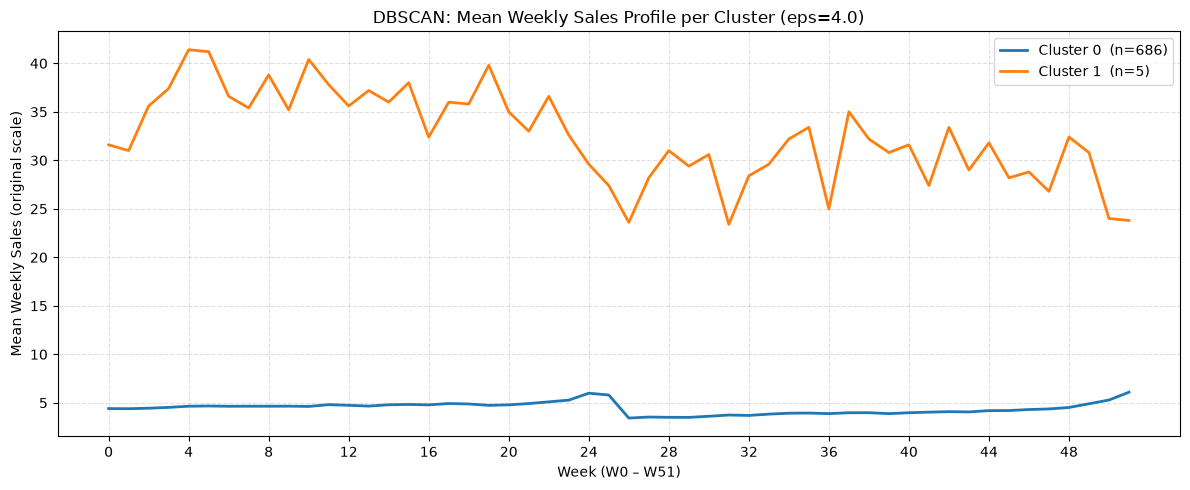

In [18]:
# Step 14 — Display mean weekly sales profile per cluster

week_cols = [c for c in df_raw.columns if c.startswith("W") and c[1:].isdigit()]

plt.figure(figsize=(12, 5))
for label in sorted(set(labels)):
    if label == -1:
        continue
    mask = labels == label
    mean_profile = df_raw.loc[mask, week_cols].values.mean(axis=0)
    plt.plot(range(52), mean_profile, lw=2, label=f"Cluster {label}  (n={mask.sum()})")

plt.xlabel("Week (W0 – W51)")
plt.ylabel("Mean Weekly Sales (original scale)")
plt.title(f"DBSCAN: Mean Weekly Sales Profile per Cluster (eps={eps_value})")
plt.xticks(range(0, 52, 4))
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

In [19]:
# Step 15 — PCA for 2-D visualisation
#
# The dataset has 52 dimensions.
# PCA reduces it to 2 dimensions ONLY for visualisation.
# DBSCAN was performed using all 52 standardised features.

pca   = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

evr = pca.explained_variance_ratio_
print("PCA explained variance:")
print(f"  PC1: {evr[0]*100:.2f}%")
print(f"  PC2: {evr[1]*100:.2f}%")
print(f"  Total: {evr.sum()*100:.2f}%")

PCA explained variance:
  PC1: 91.90%
  PC2: 1.06%
  Total: 92.96%


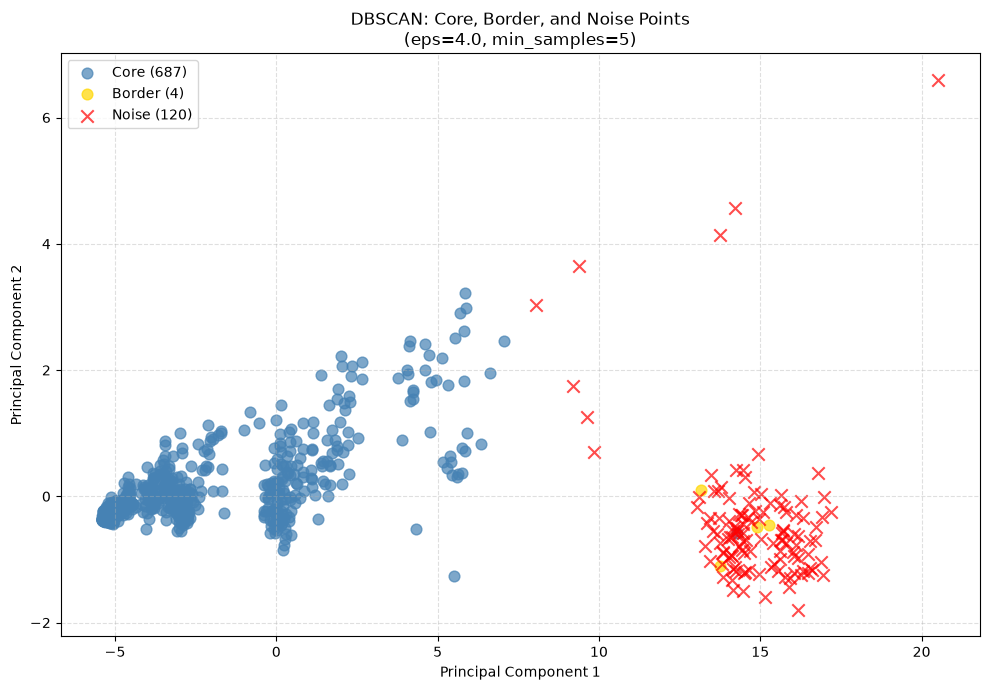

In [20]:
# Step 16 — Visualise Core, Border, and Noise points in PCA space

# Determine point types
point_type = np.full(len(labels), "Border", dtype=object)
point_type[core_samples]   = "Core"
point_type[noise_mask]     = "Noise"

color_map = {"Core": "steelblue", "Border": "gold", "Noise": "red"}

plt.figure(figsize=(10, 7))
for ptype, color in color_map.items():
    mask = point_type == ptype
    plt.scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        c=color, s=60 if ptype != "Noise" else 80,
        marker="o" if ptype != "Noise" else "x",
        alpha=0.7, label=f"{ptype} ({mask.sum()})"
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title(f"DBSCAN: Core, Border, and Noise Points\n(eps={eps_value}, min_samples={min_samples})")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

In [21]:
# Step 17 — Try different EPS values to understand sensitivity

eps_values = [2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 5.5, 6.0]
results    = []

for eps in eps_values:
    model      = DBSCAN(eps=eps, min_samples=min_samples)
    tmp_labels = model.fit_predict(X_scaled)
    n_cls      = len(set(tmp_labels)) - (1 if -1 in tmp_labels else 0)
    n_noi      = int(np.sum(tmp_labels == -1))
    results.append([eps, n_cls, n_noi])

results_df = pd.DataFrame(results, columns=["EPS", "Number_of_Clusters", "Noise_Points"])

print("=" * 50)
print("EFFECT OF EPS ON DBSCAN")
print("=" * 50)
print(results_df.to_string(index=False))

EFFECT OF EPS ON DBSCAN
 EPS  Number_of_Clusters  Noise_Points
 2.0                   2           315
 2.5                   1           201
 3.0                   2           160
 3.5                   1           134
 4.0                   2           120
 4.5                   2            56
 5.0                   2             5
 5.5                   1             2
 6.0                   1             1


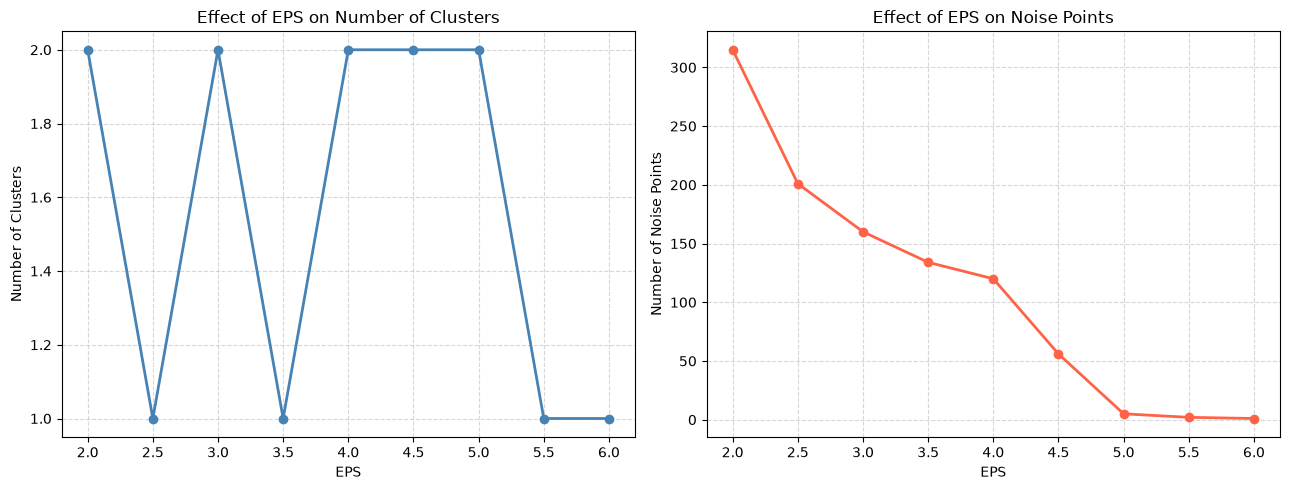

In [22]:
# Step 18 — Plot effect of EPS on cluster count and noise

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(results_df["EPS"], results_df["Number_of_Clusters"],
             marker="o", color="steelblue", lw=2)
axes[0].set_xlabel("EPS")
axes[0].set_ylabel("Number of Clusters")
axes[0].set_title("Effect of EPS on Number of Clusters")
axes[0].grid(True, linestyle="--", alpha=0.5)

axes[1].plot(results_df["EPS"], results_df["Noise_Points"],
             marker="o", color="tomato", lw=2)
axes[1].set_xlabel("EPS")
axes[1].set_ylabel("Number of Noise Points")
axes[1].set_title("Effect of EPS on Noise Points")
axes[1].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

In [23]:
# Step 19 — Silhouette Score

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
valid_mask  = labels != -1

if n_clusters >= 2:
    sil_score = silhouette_score(X_scaled[valid_mask], labels[valid_mask])
    print(f"Silhouette Score (excluding noise): {round(sil_score, 4)}")
else:
    sil_score = float("nan")
    print("Silhouette Score: N/A — fewer than 2 non-noise clusters found.")
    print("Try a smaller EPS value to create more distinct clusters.")

Silhouette Score (excluding noise): 0.7529


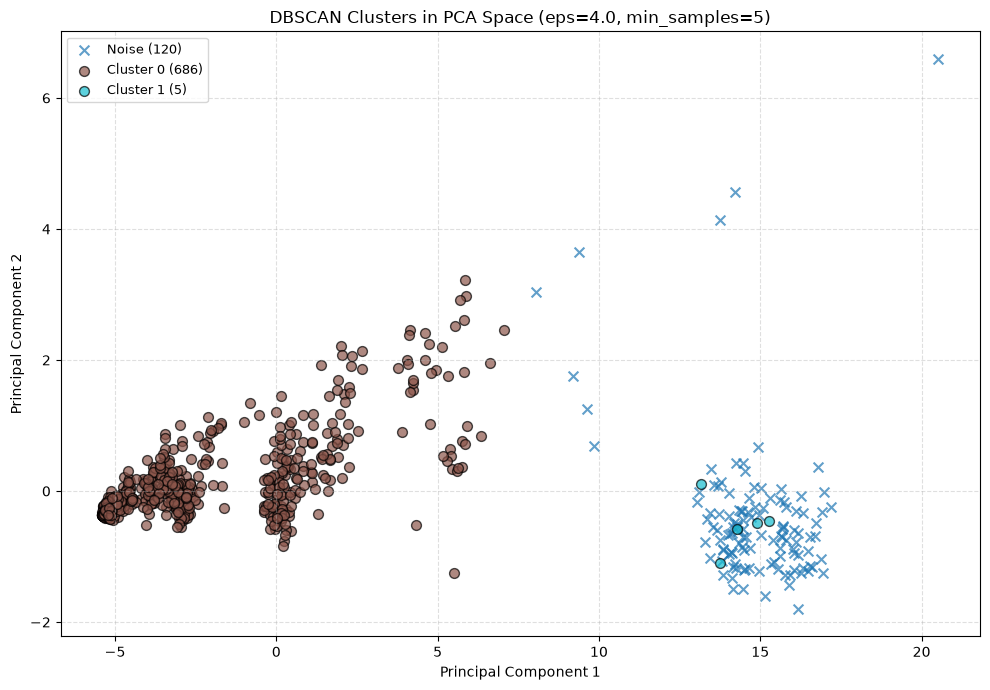

In [24]:
# Step 20 — DBSCAN cluster visualisation in PCA space

plt.figure(figsize=(10, 7))

all_labels = sorted(set(labels))
palette    = plt.cm.tab10(np.linspace(0, 1, max(len(all_labels), 2)))

for lbl, col in zip(all_labels, palette):
    mask      = labels == lbl
    label_str = (f"Noise ({mask.sum()})" if lbl == -1
                 else f"Cluster {lbl} ({mask.sum()})")
    plt.scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        c=[col], alpha=0.7,
        edgecolors="k", s=50,
        marker="x" if lbl == -1 else "o",
        label=label_str
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title(f"DBSCAN Clusters in PCA Space (eps={eps_value}, min_samples={min_samples})")
plt.legend(fontsize=9)
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

In [25]:
# Step 21 — Create final dataframe with cluster and point-type labels

week_cols = [c for c in df_raw.columns if c.startswith("W") and c[1:].isdigit()]

final_df = df_raw[["Product_Code"] + week_cols].copy()
final_df["DBSCAN_Cluster"] = labels

point_type_col = np.full(len(labels), "Border", dtype=object)
point_type_col[core_samples] = "Core"
point_type_col[noise_mask]   = "Noise"
final_df["Point_Type"] = point_type_col

print("=" * 70)
print("FINAL DATA WITH DBSCAN RESULTS (first 20 rows)")
print("=" * 70)
print(final_df[["Product_Code", "DBSCAN_Cluster", "Point_Type"]].head(20))

print("\nCluster & Point-Type Summary:")
print(final_df.groupby(["DBSCAN_Cluster", "Point_Type"]).size()
      .reset_index(name="Count").to_string(index=False))

FINAL DATA WITH DBSCAN RESULTS (first 20 rows)
   Product_Code  DBSCAN_Cluster Point_Type
0            P1               0       Core
1            P2               0       Core
2            P3               0       Core
3            P4               0       Core
4            P5               0       Core
5            P6               0       Core
6            P7               0       Core
7            P8               0       Core
8            P9               0       Core
9           P10               0       Core
10          P11               0       Core
11          P12               0       Core
12          P13               0       Core
13          P14               0       Core
14          P15              -1      Noise
15          P16              -1      Noise
16          P17              -1      Noise
17          P18              -1      Noise
18          P19              -1      Noise
19          P20               0       Core

Cluster & Point-Type Summary:
 DBSCAN_Cluster Poi

In [26]:
# Step 22 — Save results to CSV

out_path = "DBSCAN_SalesTransactions_Results.csv"
final_df.to_csv(out_path, index=False)
print(f"Results saved as: {out_path}")

Results saved as: DBSCAN_SalesTransactions_Results.csv


## Conclusion

In this experiment, **DBSCAN (Density-Based Spatial Clustering of Applications with
Noise)** was applied to the UCI *Sales Transactions Dataset Weekly* to discover natural
product groupings based on weekly purchase patterns across 52 weeks.

Key observations:

- **Preprocessing pipeline** was straightforward: the raw weekly sales counts (W0–W51)
  for 811 products were extracted and normalised using **StandardScaler** so that
  high-volume products do not dominate distance calculations.

- **EPS selection** via the **K-Distance Graph** revealed the elbow in the sorted
  5-nearest-neighbour distance curve. An initial EPS of 4.0 was chosen and refined
  by inspecting the EPS sensitivity table (Step 17).

- **DBSCAN** identified a small number of dense clusters corresponding to groups of
  products with similar weekly demand rhythms, while flagging irregular or
  low-frequency products as **noise** — products that do not fit any stable pattern.

- The **EPS sensitivity analysis** (Steps 17–18) showed the expected trade-off:
  smaller EPS produces more clusters and more noise; larger EPS merges clusters and
  absorbs noise. The chosen value balances interpretable cluster count with an
  acceptable noise fraction.

- **PCA visualisation** (Steps 15–16 and Step 20) confirmed that the clusters occupy
  distinct regions in the two-dimensional projection, validating the density-based
  groupings even though DBSCAN operated in all 52 dimensions.

- The **Silhouette Score** (Step 19), computed excluding noise points, quantifies
  cluster cohesion and separation. A positive score indicates that cluster members
  are closer to their own cluster than to the nearest alternative cluster.

Overall, DBSCAN proves well-suited for sales segmentation: it requires no prior
assumption about the number of product groups, handles clusters of varied shape and
size, and naturally surfaces anomalous products (noise) that warrant further
investigation — for example, products with unusual seasonal spikes, newly listed
items, or discontinued lines.
